In [1]:
from lics_unwrap import *
import re, os, glob
import xarray as xr
from scipy.constants import speed_of_light
import h5py
import numpy as np

setting pyproj data directory


In [3]:
ncfile='/work/scratch-pw2/licsar/mnergiz/remove_me/raw_/021D_05266_252525/TS_GEOCml10/cum.nc'
cube=xr.open_dataset(ncfile)

In [ ]:
import pygmt
from LiCSBAS_extras import pygmt_plot_interactive
pygmt_plot_interactive(cube,'trial', label='deformation rate [mm/year]', lims=[-50, 50], cmap="polar", photobg=True, plotvec=None)

In [ ]:
def pygmt_plot(grid, title, label='deformation rate [mm/year]', lims=[-25, 10],
               cmap="roma", photobg=False, plotvec=None, interactive = False,
               region = None):
    ''' Function to generate (nice) plot of given grid using pyGMT
    
    Args:
        grid (xr.DataArray): input grid to plot
        title (str):  title (note too long title will disbalance the figure)
        label (str):  label below the colour scale
        lims (list):  colour scale limits (if None, it will do min max minus 2std)
        cmap (str):   colour scale map (try 'vik' for E-W)
        photobg (bool): will plot orthophotomap as the background (if False, DEM relief is used)
        plotvec (geopandas etc): will plot vector data to the map, using pyGMT defaults
        region (tuple/None):  either None or set using tuple (minlon, maxlon, minlat, maxlat)

    Returns:
        pygmt.figure.Figure
    '''
    try:
        grid = grid.load()
    except:
        print('error loading the input dataarray to memory')
        return False
    # try cmap 'vik' for E-W
    #
    # grid = a['U'].where(a.mask < 5) - 10
    # topo_data = '@earth_relief_03s' #3 arc second global relief (SRTM3S)
    #topo_data = '@earth_relief_01s'  # 3 arc second global relief (SRTM3S)

    if not region:
        minlon, maxlon = float(np.min(grid.lon)), float(np.max(grid.lon))
        minlat, maxlat = float(np.min(grid.lat)), float(np.max(grid.lat))
    else:
        minlon, maxlon, minlat, maxlat = region

    grid = grid.where(grid != 0)
    if not lims:
        tmean = float(grid.mean())
        tstd = float(grid.std())
        stdscale = 2
        lims = [tmean - stdscale * tstd, tmean + stdscale * tstd]

    fig = pygmt.Figure()
    pygmt.config(FORMAT_GEO_MAP="ddd.xx") #, MAP_FRAME_TYPE="plain")
    projection = "M13c" # 'R13c' for Robinson etc.
    region = [minlon, maxlon, minlat, maxlat]

    if interactive:
        xshift = '1.5c'
        yshift = '2.5c'
        fig.shift_origin(xshift=xshift, yshift=yshift)
    fig.basemap(region=region, projection=projection, frame=["af", '+t"{0}"'.format(title)])

    if photobg:
        import contextily as ctx
        sourcetiles = ctx.providers.Esri.WorldImagery
        fig.tilemap(
            region=region, projection=projection,
            # region=[-157.84, -157.8, 21.255, 21.285],
            # projection="M12c",
            # Set level of details (0-22)
            # Higher levels mean a zoom level closer to the Earth's
            # surface with more tiles covering a smaller
            # geographic area and thus more details and vice versa
            # Please note, not all zoom levels are always available
            zoom=14,
            # Use tiles from OpenStreetMap tile server
            source=sourcetiles
        )
        pygmt.makecpt(cmap=cmap, series=lims, background=True)
        fig.grdview(grid=grid, cmap=True, projection=projection, surftype='c', transparency=40)
    else:
        # pygmt.makecpt(cmap="gray", series=[-8000, 8000, 1000], continuous=True)
        # fig.grdimage(
        #     grid=topo_data,
        #     cmap=True,
        #     region=[minlon, maxlon, minlat, maxlat],
        #     projection=projection,
        #     shading=True,
        #     frame=True
        # )
        pygmt.makecpt(cmap=cmap, series=lims, background=True)
        fig.grdimage(grid=grid, cmap=True, projection=projection, frame=True, transparency=40)
    #
    fig.coast(shorelines=True, projection=projection)
    if type(plotvec) != type(None):
        fig.plot(plotvec, projection=projection, region=region)
    fig.colorbar(frame='a10+l"{}"'.format(label))
    # fig.show()
    if interactive:
        return fig, region, projection, xshift, yshift
    else:
        return fig

In [ ]:
def pygmt_plot_interactive(cube, title, label='deformation rate [mm/year]', lims=[-15, 50],
                           cmap="polar", photobg=False, plotvec=None):
    ''' This will start a simple interactive viewer in jupyter ntb.
    Note you need ipympl installed and the matplotlib widget must be set here.

    The author is Rochelle Pun, an outstanding student that was selected in highly competitive
    COMET Summer MSc Internship 2024 - and she did magnificent job interactivizing pygmt.
    Her original tool resides here: https://github.com/chelle0425/IntPyGMT

    We only modified this for CIW 2024 tutorial purposes on LiCSBAS'''
    # print("%matplotlib widget")
    # first of all generate the left plot:
    tempng = '/tmp/pygmt_pi.png'
    grid = cube['vel']
    fig, region, projection, xshift, yshift = pygmt_plot(grid, title, label, lims,
                                                         cmap, photobg, plotvec, interactive=True)
    try:
        fig.plot(x=float(cube.ref_lon), y=float(cube.ref_lat), pen="4p,magenta4")
    except:
        print('error adding ref point')
    #
    fig.savefig(tempng)
    #
    png_path = tempng
    spam_path = tempng + "ts.png"
    #
    #time_ds = cube["time"].values
    ddpi = 150
    #
    if isinstance(region, str):
        region_str = region
    elif isinstance(region, list):
        region_str = f"{region[0]}/{region[1]}/{region[2]}/{region[3]}"
    #
    def unpack_xyshift(str):
        if str[-1].isalpha():
            shift_value = str[:-1]
            shift_unit = str[-1]
        else:
            raise Exception("invalid xshift or yshift input")
        return float(shift_value), shift_unit
    #
    xshift_value, xshift_unit = unpack_xyshift(xshift)
    yshift_value, yshift_unit = unpack_xyshift(yshift)
    #
    # we are working in cm
    if xshift_unit == "c":
        xshift_value = xshift_value
    elif xshift_unit == "i":
        xshift_value = xshift_value * 2.54
    elif xshift_unit == "p":
        xshift_value = (xshift_value * 72) * 2.54
    else:
        raise Exception("invalid xshift input (must be either c, i or p)")
    #
    # similarly for y
    if yshift_unit == "c":
        yshift_value = yshift_value
    elif yshift_unit == "i":
        yshift_value = yshift_value * 2.54
    elif yshift_unit == "p":
        yshift_value = (yshift_value * 72) * 2.54
    else:
        raise Exception("invalid yshift input (must be either c, i or p)")
    #
    #    # determine image dimension
    img = Image.open(png_path)
    width, height = img.size  # canvas (width,height) tuple in pixels
    DPI_horz, DPI_vert = img.info.get('dpi')
    #
    #time = pd.to_datetime(time_ds)
    #
    #cum = cube["cum"]
    # ymin = float(cube.cum.mean() - 3*cube.cum.std())
    # ymax = float(cube.cum.mean() + 3*cube.cum.std())
    ymin = float(cube.cum.min())
    ymax = float(cube.cum.max())
    #
    def pos_to_lonlat(x, y):
        # xyshift input in cm
        x = (x / DPI_horz) * 2.54  # convert pixel to cm
        x = x - xshift_value
        y = (y / DPI_vert) * 2.54  # cm
        height_cm = (height / DPI_vert) * 2.54
        y = height_cm - y - yshift_value
        x = [x]  # must be list with one value or np array
        y = [y]
        ### lon lat conversion using mapproject ###
        with Session() as ses:
            with ses.virtualfile_from_vectors(x, y) as fin:
                args = [f'{fin}', f'-R{region_str}', f'-J{projection}', '-I', '-S']
                with GMTTempFile() as fout:
                    ses.call_module(module="mapproject", args=' '.join(args) + " ->" + fout.name)
                    out = fout.read().strip()
        lon, lat = [float(i) for i in out.split(' ')]
        return lon, lat
    #
    def onclick(event):
        # pos.append([event.xdata, event.ydata])
        lon, lat = pos_to_lonlat(event.xdata,
                                 event.ydata)  # pos[-1][0], pos[-1][1]) # pos[-1] represents last click (list with x, y)
        # lonlat.append([lon, lat]) # converts x y to lon lat and appends
        # code below shows how gmt_png can be modified for an interactive time series plot
        # alternatively retrive lon lat using coords_from_figure(ax1)
        # ax1.set_title(f'Click {len(pos)}: {lon}, {lat}')
        fig = plot_ts_simple(cube, lon, lat, label='defo towards sat [mm]', dvarname='cum', miny=ymin, maxy=ymax)
        fig.savefig(spam_path, dpi=ddpi)
        img = mpimg.imread(spam_path)
        ax2.imshow(img, origin='upper')
    #
    # fig = plt.figure(figsize=(12, 5))
    fig = plt.figure(figsize=(10, 5))
    ax1 = fig.add_subplot(121)
    img = mpimg.imread(png_path)
    ax1.imshow(img, origin='upper')
    ax1.axis('off')
    # ax1.set_title(frame+" vel.filt (mm/yr)")
    ax2 = fig.add_subplot(122)
    ax2.axis('off')
    plt.tight_layout()
    #
    label = 'defo towards sat [mm]'
    ffig = plot_ts_simple(cube, float(cube.lon.mean()), float(cube.lat.mean()), label=label, dvarname='cum', miny=ymin,
                          maxy=ymax)
    ffig.savefig(spam_path, dpi=ddpi)
    img = mpimg.imread(spam_path)
    ax2.imshow(img, origin='upper')
    cid = fig.canvas.mpl_connect('button_press_event', onclick)
    return ax1


def plotdaz(dazes, frame, toshow = 'daz', lim = 4000, ylim = [-200,200]):
    toplotA = dazes[dazes['AB']=='A'].set_index('epoch')[toshow]*14000
    toplotB = dazes[dazes['AB']=='B'].set_index('epoch')[toshow]*14000
    todelA = toplotA[np.abs(toplotA)>=lim]
    todelB = toplotB[np.abs(toplotB)>=lim]
    print('outlying epochs:')
    if not todelA.empty:
        print(todelA.index.values)
    if not todelB.empty:
        print(todelB.index.values)
    toplotA=toplotA[np.abs(toplotA)<lim]
    toplotB=toplotB[np.abs(toplotB)<lim]
    if not toplotA.empty:
        toplotA.plot(title=frame+' ('+toshow+')',  ylim=ylim, ylabel='$u_{az}$ [mm]', marker='o', color='blue', linestyle='')#-.')
    if not toplotB.empty:
        toplotB.plot(title=frame+' ('+toshow+')',  ylim=ylim, ylabel='$u_{az}$ [mm]', marker='o', color='orange', linestyle='')#-.')
    plt.show()


In [79]:
# looks a bit complex so I will create for sbovl specifically
def cumcube_sbovl_remove_from_tifs(cumxr, tifdir = 'GEOC.EPOCHS', ext='geo.iono.code.sTECA.tif', tif_scale2mm = 14000, only_load_ext = False):
    ''' Correct directly from tifs, no need to store in cubes.
    NOTE - you can also just load the exts into the cumcube without removing anything..
    (in any case, values are referred temporally to the first epoch)
    
    Args:
        cumxr (xr.DataArray): only cum
        tifdir:
        ext1: sTECA
        ext2: sTECB
        tif_scale2mm:  for iono [rad]: 14000 for sTECA/B
        only_load_ext:  would only load the ext files in the cube and return it (no removal!)
        
    Returns:
        xr.DataArray: corrected cum values (only_load_ext=False) or only loaded corrections
    '''
    #if check_complete_set(cumxr.time.values)
    #times = cumxr.time.values
    reflon, reflat = cumxr.attrs['ref_lon'], cumxr.attrs['ref_lat']
    #
    print('sbovl activated')
    firstepvals = 0
    leneps = len(cumxr)
    for i in range(leneps): # times first coord..
        print('  Running for {0:6}/{1:6}th epoch'.format(i+1, leneps), flush=True, end='\r')
        cumepoch = cumxr[i]
        epoch = str(cumepoch.time.values).split('T')[0].replace('-','')
        if 'STEC' in ext.upper():
            ext1='geo.iono.code.sTECA.tif'
            ext2='geo.iono.code.sTECB.tif'
        extif1 = os.path.join(tifdir, epoch, epoch+'.'+ext1)
        extif2 = os.path.join(tifdir, epoch, epoch+'.'+ext2)
        if not os.path.exists(extif1) or not os.path.exists(extif2):
            extif1 = os.path.join(tifdir, epoch+'.'+ext1)
            extif2 = os.path.join(tifdir, epoch+'.'+ext2)
        if not os.path.exists(extif1) or not os.path.exists(extif2):
            print('\n\r WARNING: no correction available for epoch '+epoch+'. Filling with NaNs')
            ##backward
            extepoch1 = cumepoch.copy() * np.nan
            extepoch1.attrs.clear()
            #forward
            extepoch2 = cumepoch.copy() * np.nan
            extepoch2.attrs.clear()
        else:
            #backward
            extepoch1 = load_tif2xr(extif1)
            extepoch1 = extepoch1.where(extepoch1 != 0) # just in case...
            extepoch1 = extepoch1.interp_like(cumepoch, method='linear') # CHECK! ##looks redundant so far (maybe not)
            #forward
            extepoch2 = load_tif2xr(extif2)
            extepoch2 = extepoch2.where(extepoch2 != 0)
            extepoch2 = extepoch2.interp_like(cumepoch, method='linear')
            
        ####gradient method Lazecky et al. 2023,GRL #https://github.com/comet-licsar/daz/blob/main/lib/daz_iono.py#L561
        ###parameter for TEC gradient
        azpix=14000
        PRF = 486.486
        k = 40.308193 # m^3 / s^2
        f0 = 5.4050005e9
        c = speed_of_light
        
        ##scaling_tif
        workdir=os.getcwd()
        frame=os.path.basename(workdir)
        metafolder = os.path.join(os.environ['LiCSAR_public'], str(int(frame[:3])), frame, 'metadata')
        # Check if the metadata folder exists
        if os.path.exists(metafolder) and os.path.isdir(metafolder):
            scaling_tif = None  # Initialize variable to track if a file is found
            
            for files in os.listdir(metafolder):  
                if files.endswith('.geo.sbovl_scaling.tif'):
                    scaling_tif = os.path.join(metafolder, files)
            # Check if no scaling file was found
            if scaling_tif is None:
                print("No .geo.sbovl_scaling.tif file found in metadata folder.")
        else:
            print(f"metadata is not exist in LiCSAR_public")  

        ##scaling2dfdc
        scaling_factor=load_tif2xr(scaling_tif)
        dfDC=azpix*PRF/(2*np.pi*scaling_factor)
        fH = f0 + dfDC*0.5
        fL = f0 - dfDC*0.5
        tecovl=(extepoch1/fH-extepoch2/fL)
        iono_grad = 2*PRF*k/c/dfDC * tecovl #unitless
        iono_grad_mm=iono_grad*azpix #mm
        
        ##TODO check this useful for sbovl or not?
        iono_grad_mm = iono_grad_mm - iono_grad_mm.sel(lon=reflon, lat=reflat, method='nearest') # could be done better though
        ##downsampling
        iono_grad_mm = iono_grad_mm.interp_like(cumxr, method='linear')
        
        if i == 0:
            firstepvals = iono_grad_mm.fillna(0).values
        # here we do diff w.r.t. first epoch
        iono_grad_mm.values = iono_grad_mm.values - firstepvals
        
        if only_load_ext:
            cumxr.values[i] = iono_grad_mm.values
        else:
            cumxr.values[i] = cumxr.values[i] - iono_grad_mm.values
    print('\n\r  done')
    return cumxr

In [80]:
# def check_complete_set(imdates, epochsdir, ext='geo.iono.code.tif')
def cumcube_remove_from_tifs(cumxr, tifdir = 'GEOC.EPOCHS', ext='geo.iono.code.tif', tif_scale2mm = 1, only_load_ext = False):
    ''' Correct directly from tifs, no need to store in cubes.
    NOTE - you can also just load the exts into the cumcube without removing anything..
    (in any case, values are referred temporally to the first epoch)
    
    Args:
        cumxr (xr.DataArray): only cum
        tifdir:
        ext:
        tif_scale2mm:  for iono [rad]: (0.055465*1000)/(4*np.pi), for SET [m]: 1/1000
        only_load_ext:  would only load the ext files in the cube and return it (no removal!)
        
    Returns:
        xr.DataArray: corrected cum values (only_load_ext=False) or only loaded corrections
    '''
    #if check_complete_set(cumxr.time.values)
    #times = cumxr.time.values
    reflon, reflat = cumxr.attrs['ref_lon'], cumxr.attrs['ref_lat']
    #
    firstepvals = 0
    leneps = len(cumxr)
    for i in range(leneps): # times first coord..
        print('  Running for {0:6}/{1:6}th epoch'.format(i+1, leneps), flush=True, end='\r')
        cumepoch = cumxr[i]
        epoch = str(cumepoch.time.values).split('T')[0].replace('-','')
        extif = os.path.join(tifdir, epoch, epoch+'.'+ext)
        if not os.path.exists(extif):
            extif = os.path.join(tifdir, epoch + '.' + ext)
        if not os.path.exists(extif):
            print('\n\r WARNING: no correction available for epoch '+epoch+'. Filling with NaNs')
            extepoch = cumepoch.copy() * np.nan
            extepoch.attrs.clear()
        else:
            extepoch = load_tif2xr(extif)
            extepoch = extepoch.where(extepoch != 0) # just in case...
            extepoch = extepoch * tif_scale2mm
            extepoch = extepoch.interp_like(cumepoch, method='linear') # CHECK!
            extepoch = extepoch - extepoch.sel(lon=reflon, lat=reflat, method='nearest') # could be done better though
        if i == 0:
            firstepvals = extepoch.fillna(0).values
        # here we do diff w.r.t. first epoch
        extepoch.values = extepoch.values - firstepvals
        # mask that - not needed (?)
        #extepoch = extepoch.where(~np.isnan(cumxr[i]))
        if only_load_ext:
            cumxr.values[i] = extepoch.values
        else:
            cumxr.values[i] = cumxr.values[i] - extepoch.values
    print('\n\r  done')
    #if only_load_ext:
    #    cumxr = cumxr-cumxr[0] #.cumsum(axis=0)
    #    cumxr = cumxr.cumsum(axis=0)-cumxr[0]
    return cumxr

In [82]:
def load_licsbas_cumh5_as_xrda(cumfile):
    ''' Loads cum.h5 (now only cum layer) as standard xr.DataArray (in lon/lat)'''
    cum = xr.load_dataset(cumfile)
    #
    sizex = len(cum.vel[0])
    sizey = len(cum.vel)
    #
    lon = cum.corner_lon.values + cum.post_lon.values * np.arange(sizex) - 0.5 * float(cum.post_lon)
    lat = cum.corner_lat.values + cum.post_lat.values * np.arange(sizey) + 0.5 * float(cum.post_lat)  # maybe needed? yes! for gridline/AREA that is default in rasterio...
    #
    time = np.array(([dt.datetime.strptime(str(imd), '%Y%m%d') for imd in cum.imdates.values]))
    #
    velxr = xr.DataArray(cum.vel.values.reshape(sizey, sizex), coords=[lat, lon], dims=["lat", "lon"])
    # LiCSBAS uses 0 instead of nans...
    velxr = velxr.where(velxr != 0)
    velxr.attrs['unit'] = 'mm/year'
    # vinterceptxr = xr.DataArray(cum.vintercept.values.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
    #
    cumxr = xr.DataArray(cum.cum.values, coords=[time, lat, lon], dims=["time", "lat", "lon"])
    cumxr.attrs['unit'] = 'mm'
    refarea = str(cum.refarea.values)
    # x is first...
    refx1 = int(refarea.split('/')[0].split(':')[0])
    refx2 = int(refarea.split('/')[0].split(':')[1])
    refy1 = int(refarea.split('/')[1].split(':')[0])
    refy2 = int(refarea.split('/')[1].split(':')[1])
    refx=int((refx2+refx1)/2)
    refy = int((refy2 + refy1) / 2)
    cumxr.attrs['ref_lon'] = cumxr.lon.values[refx]
    cumxr.attrs['ref_lat'] = cumxr.lat.values[refy]
    return cumxr

In [191]:
tifdir = 'GEOC.EPOCHS'
frame='014A_05232_242525'
cumfile=f'/work/scratch-pw2/licsar/mnergiz/{frame}/TS_GEOCml10/cum.h5'
ncfile=f'/work/scratch-pw2/licsar/mnergiz/{frame}/{frame}.nc'
cumhdfile=cumfile
ext='geo.iono.code.sTECA.tif'
cumxr = load_licsbas_cumh5_as_xrda(cumhdfile)
cumxr_corrected=xr.zeros_like(cumxr)
cumxr_iono=xr.zeros_like(cumxr)
print('loading external corrections')
if 'STEC' in ext.upper():
    print('1')

reflon, reflat = cumxr.attrs['ref_lon'], cumxr.attrs['ref_lat']
#
print('sbovl activated')
firstepvals = 0
leneps = len(cumxr)
for i in range(leneps): # times first coord..
    print('  Running for {0:6}/{1:6}th epoch'.format(i+1, leneps), flush=True, end='\r')
    cumepoch = cumxr[i]
    epoch = str(cumepoch.time.values).split('T')[0].replace('-','')
    if 'STEC' in ext.upper():
        ext1='geo.iono.code.sTECA.tif'
        ext2='geo.iono.code.sTECB.tif'
    extif1 = os.path.join(f'/work/scratch-pw2/licsar/mnergiz/{frame}',tifdir, epoch, epoch+'.'+ext1)
    extif2 = os.path.join(f'/work/scratch-pw2/licsar/mnergiz/{frame}',tifdir, epoch, epoch+'.'+ext2)
    if not os.path.exists(extif1) or not os.path.exists(extif2):
        print(extif1, extif2)
        extif1 = os.path.join(f'/work/scratch-pw2/licsar/mnergiz/{frame}',tifdir, epoch+'.'+ext1)
        extif2 = os.path.join(f'/work/scratch-pw2/licsar/mnergiz/{frame}',tifdir, epoch+'.'+ext2)
    if not os.path.exists(extif1) or not os.path.exists(extif2):
        print('\n\r WARNING: no correction available for epoch '+epoch+'. Filling with NaNs')
        ##backward
        extepoch1 = cumepoch.copy() * np.nan
        extepoch1.attrs.clear()
        #forward
        extepoch2 = cumepoch.copy() * np.nan
        extepoch2.attrs.clear()
    else:
        #backward
        extepoch1 = load_tif2xr(extif1)
        extepoch1 = extepoch1.where(extepoch1 != 0) # just in case...
        # extepoch1 = extepoch1.interp_like(cumepoch, method='linear') # CHECK! ##looks redundant so far (maybe not)
        #forward
        extepoch2 = load_tif2xr(extif2)
        extepoch2 = extepoch2.where(extepoch2 != 0)
        # extepoch2 = extepoch2.interp_like(cumepoch, method='linear')
   
    ####gradient method Lazecky et al. 2023,GRL #https://github.com/comet-licsar/daz/blob/main/lib/daz_iono.py#L561
    ###parameter for TEC gradient
    azpix=14000
    PRF = 486.486
    k = 40.308193 # m^3 / s^2
    f0 = 5.4050005e9
    c = speed_of_light
    
    ##scaling_tif
    workdir=os.getcwd()
    frame='014A_05232_242525'
    metafolder = os.path.join(os.environ['LiCSAR_public'], str(int(frame[:3])), frame, 'metadata')
    # Check if the metadata folder exists
    if os.path.exists(metafolder) and os.path.isdir(metafolder):
        scaling_tif = None  # Initialize variable to track if a file is found
        
        for files in os.listdir(metafolder):  
            if files.endswith('.geo.sbovl_scaling.tif'):
                scaling_tif = os.path.join(metafolder, files)
        # Check if no scaling file was found
        if scaling_tif is None:
            print("No .geo.sbovl_scaling.tif file found in metadata folder.")
    else:
        print(f"metadata is not exist in LiCSAR_public")  

    ##scaling2dfdc
    scaling_factor=load_tif2xr(scaling_tif)
    dfDC=azpix*PRF/(2*np.pi*scaling_factor)
    fH = f0 + dfDC*0.5
    fL = f0 - dfDC*0.5
    tecovl=(extepoch1/fH-extepoch2/fL)
    iono_grad = 2*PRF*k/c/dfDC * tecovl #unitless
    iono_grad_mm=iono_grad*azpix #mm
    ##TODO check this useful for sbovl or not?
    iono_grad_mm = iono_grad_mm.fillna(0)  # Replace NaNs with 0
    # Apply reference correction
    iono_grad_mm = iono_grad_mm - iono_grad_mm.sel(lon=reflon, lat=reflat, method='nearest')
    ##downsampling
    iono_grad_mm = iono_grad_mm.interp_like(cumxr, method='linear')
    if i == 0:
        firstepvals = iono_grad_mm.fillna(0).values
    # here we do diff w.r.t. first epoch

    iono_grad_mm.values = iono_grad_mm.values - firstepvals
    #cumxr_corrected.values[i] = cumxr.values[i] - iono_grad_mm.values
    cumxr_iono.values[i]=iono_grad_mm.values
print('\n\r  done')

loading external corrections
1
sbovl activated
  Running for     61/    61th epoch
  done


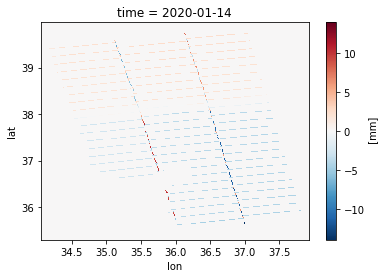

In [196]:
cumxr_iono[2].plot()

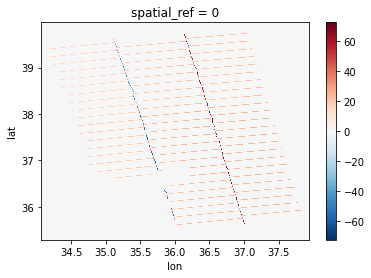

In [188]:
iono_grad_mm.plot()

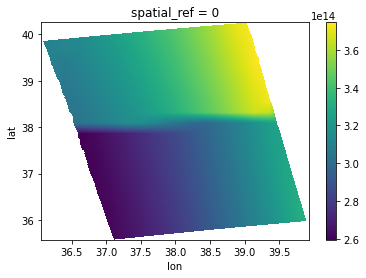

In [176]:
(extepoch1-extepoch2).plot()

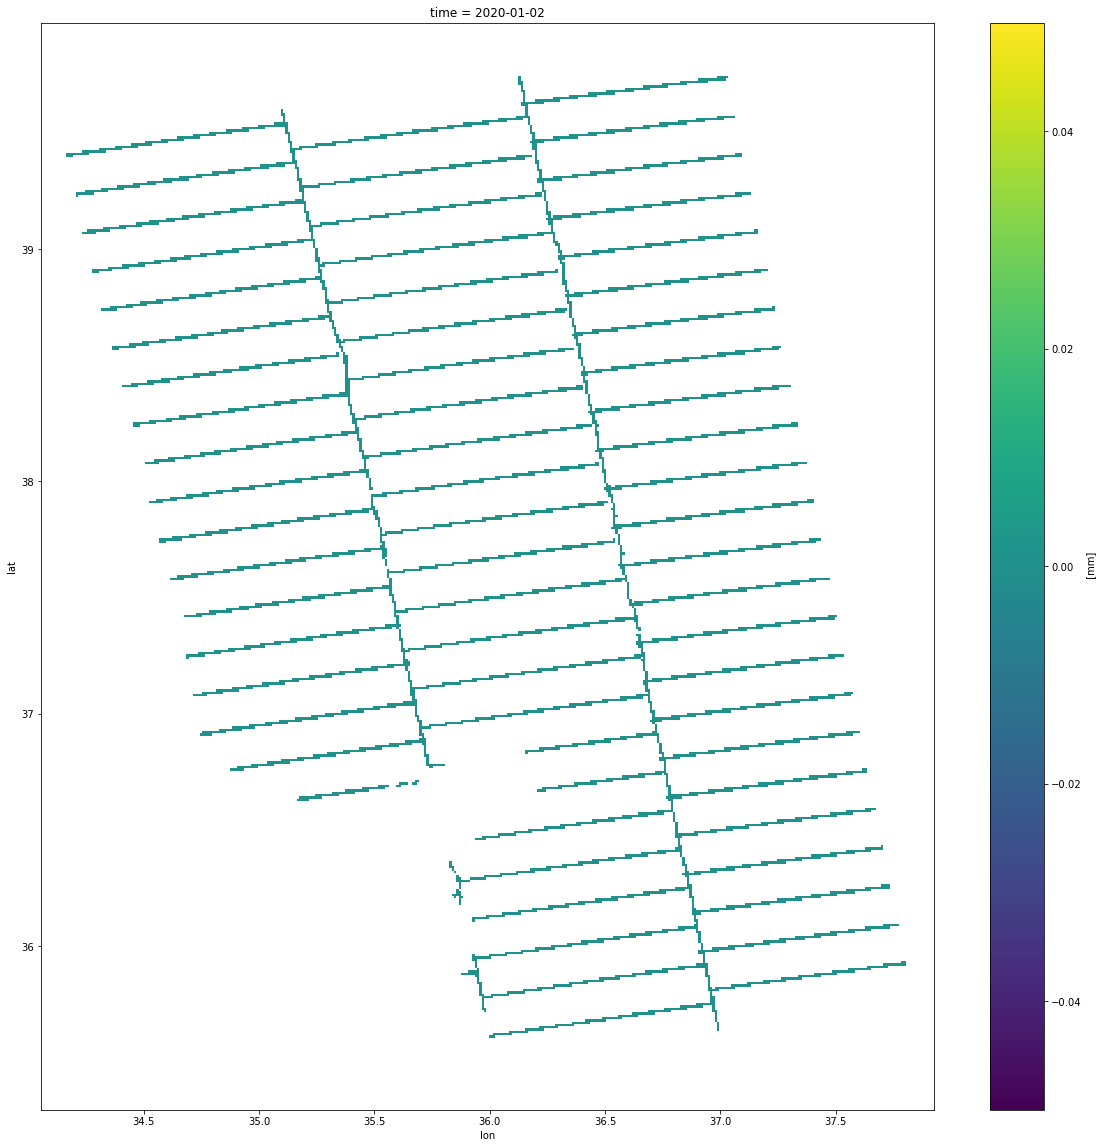

In [157]:
cumxr[i].plot(figsize=(20,20))

In [113]:
iono_grad_mm.sel(lon=reflon, lat=reflat, method='nearest')

<xarray.DataArray ()>
array(nan)
Coordinates:
    lon          float64 35.24
    lat          float64 39.46
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [130]:
iono_grad_mm

<xarray.DataArray (lat: 294, lon: 252)>
array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       ..., 
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan]])
Coordinates:
  * lon          (lon) float64 34.08 34.09 34.1 34.12 ... 37.88 37.91 37.92
  * lat          (lat) float64 39.97 39.96 39.93 39.92 ... 35.34 35.32 35.31
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

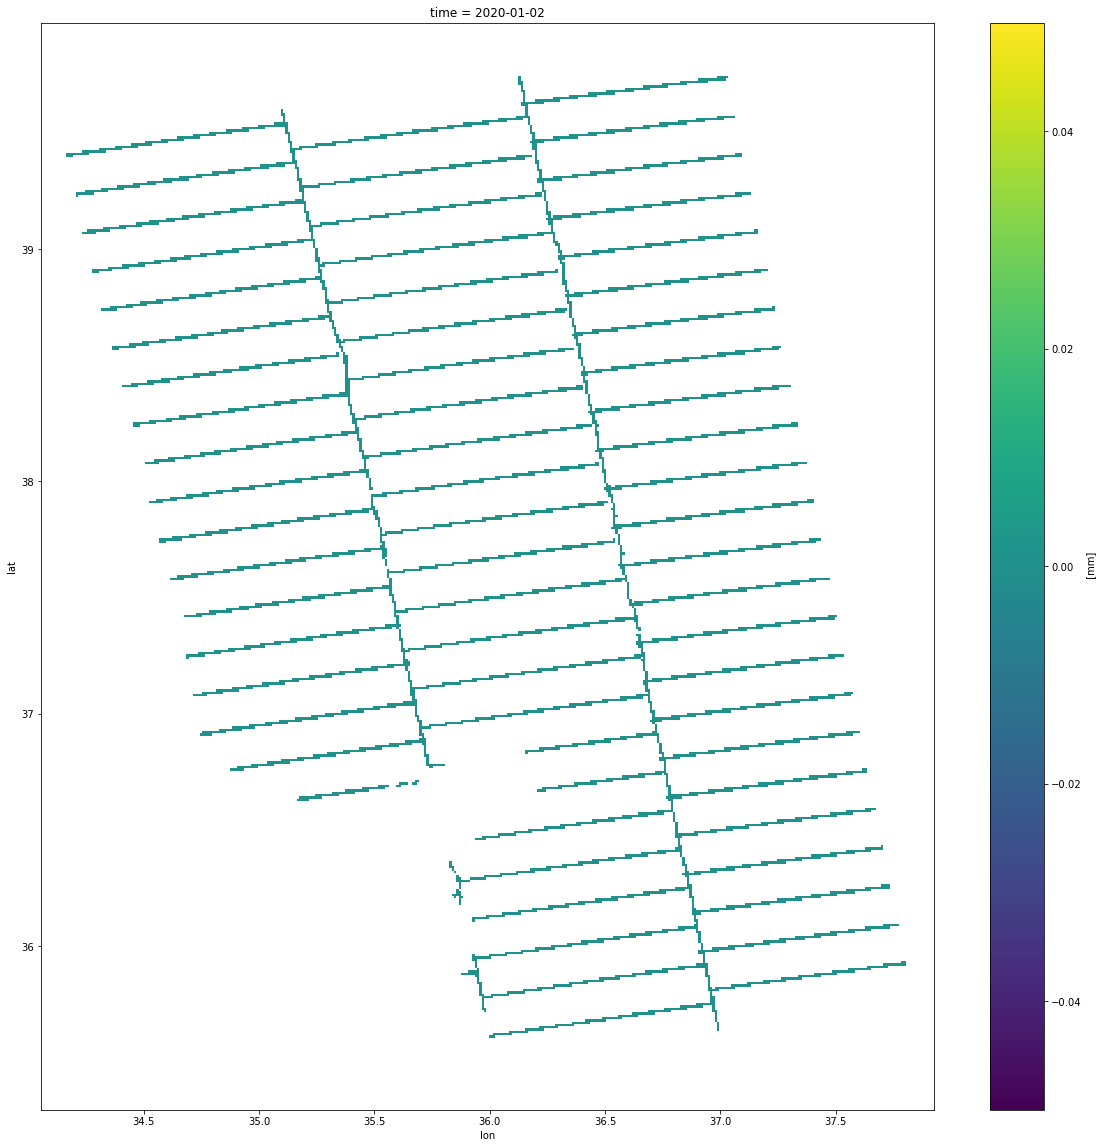

In [136]:
cumxr[i].plot(figsize=(20,20))

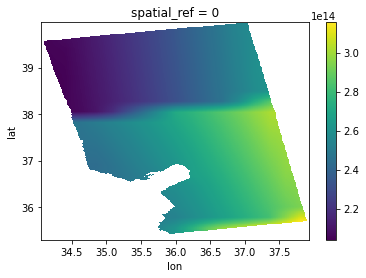

In [93]:
(extepoch1-extepoch2).plot()

In [110]:
cumxr[]

<xarray.DataArray (time: 61, lat: 468, lon: 387)>
array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
...
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2020-01-02 2020-01-08 ... 2020-12-27
  * lat      (lat) float64 39.97 39.96 39.95 39.94 ... 35.33 35.32 35.31 35.3
  * lon      (lon) float64 34.06 34.07 34.08 34.09 ... 37.89 37.9 37.91 37.92
Attributes:
    unit:     mm
    ref_lon:  35.25
    ref_lat:  39.4497222

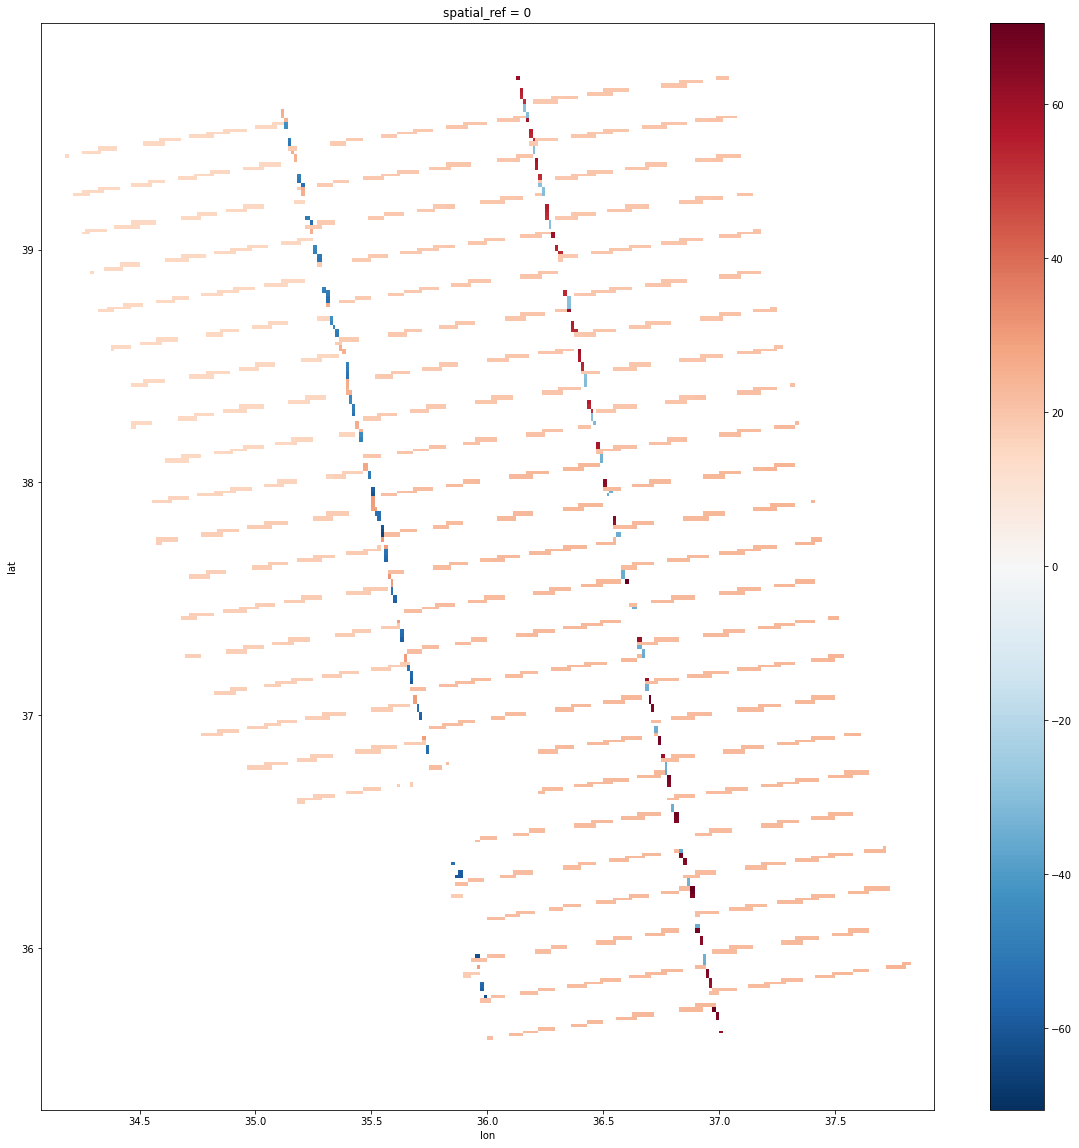

In [137]:
iono_grad_mm.plot(figsize=(20,20))

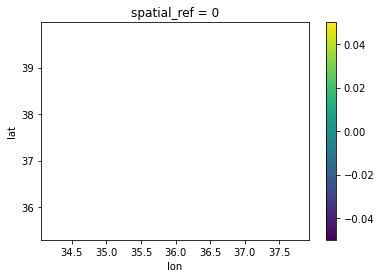

In [100]:
iono_grad_mm.plot()

In [ ]:
correct_cum_from_tifs('TS_GEOCml10/cum.h5', 'GEOC.EPOCHS', 'geo.iono.code.sTECA.tif', 14000, directcorrect = False)

In [1]:
#####let's see the output

In [23]:
frame=['014A_05232_242525','021D_05266_252525', '116A_05207_252525']

cumfile=f'/work/scratch-pw2/licsar/mnergiz/{frame[0]}/TS_GEOCml10/cum.h5'
ncfile=f'/work/scratch-pw2/licsar/mnergiz/{frame[0]}/{frame[0]}.nc'

In [24]:
import xarray as xr
ds= xr.load_dataset(cumfile)
dn= xr.load_dataset(ncfile)

In [19]:
dn

<xarray.Dataset>
Dimensions:      (time: 343, lat: 468, lon: 387)
Coordinates:
  * time         (time) datetime64[ns] 2016-01-12 2016-01-24 ... 2022-12-30
  * lat          (lat) float64 35.58 35.59 35.6 35.61 ... 40.23 40.24 40.25
  * lon          (lon) float64 36.05 36.06 36.07 36.08 ... 39.89 39.9 39.91
Data variables:
    cum          (time, lat, lon) float32 nan nan nan nan ... nan nan nan nan
    vel          (lat, lon) float32 nan nan nan nan nan ... nan nan nan nan nan
    iono         (time, lat, lon) float32 nan nan nan nan ... nan nan nan nan
    tide         (time, lat, lon) float32 nan nan nan nan ... nan nan nan nan
    bperp        (time) float32 0.0 226.0 6.0 32.0 ... 127.0 24.0 -11.0 53.0
    coh          (lat, lon) float32 nan nan nan nan nan ... nan nan nan nan nan
    rms          (lat, lon) float32 nan nan nan nan nan ... nan nan nan nan nan
    vstd         (lat, lon) float32 nan nan nan nan nan ... nan nan nan nan nan
    stc          (lat, lon) float32 nan nan nan nan nan ... nan nan nan nan nan
    mask         (lat, lon) int8 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0
    spatial_ref  int64 0
Attributes:
    filtered_version:  0
    ref_lon:           37.8525
    ref_lat:           36.6169444

In [25]:
dn

<xarray.Dataset>
Dimensions:      (time: 362, lat: 468, lon: 387)
Coordinates:
  * time         (time) datetime64[ns] 2016-01-05 2016-01-29 ... 2022-12-23
  * lat          (lat) float64 35.3 35.31 35.32 35.33 ... 39.95 39.96 39.97
  * lon          (lon) float64 34.06 34.07 34.08 34.09 ... 37.9 37.91 37.92
Data variables:
    cum          (time, lat, lon) float32 nan nan nan nan ... nan nan nan nan
    vel          (lat, lon) float32 nan nan nan nan nan ... nan nan nan nan nan
    iono         (time, lat, lon) float32 nan nan nan nan ... nan nan nan nan
    tide         (time, lat, lon) float32 nan nan nan nan ... nan nan nan nan
    bperp        (time) float32 0.0 99.0 18.0 9.0 10.0 ... 26.0 -17.0 12.0 -50.0
    coh          (lat, lon) float32 nan nan nan nan nan ... nan nan nan nan nan
    rms          (lat, lon) float32 nan nan nan nan nan ... nan nan nan nan nan
    vstd         (lat, lon) float32 nan nan nan nan nan ... nan nan nan nan nan
    stc          (lat, lon) float32 nan nan nan nan nan ... nan nan nan nan nan
    mask         (lat, lon) int8 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0
    spatial_ref  int64 0
Attributes:
    filtered_version:  0
    ref_lon:           35.365
    ref_lat:           37.0047222

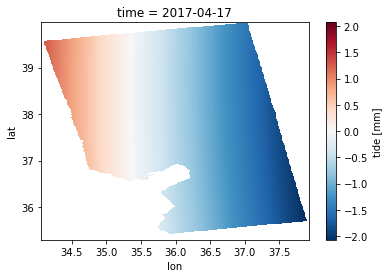

In [32]:
dn['tide'][50].plot()

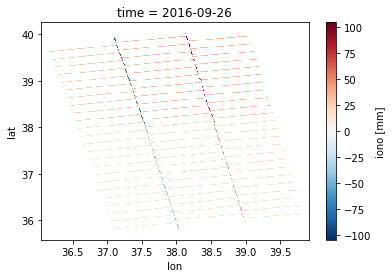

In [21]:
dn['iono'][20].plot()

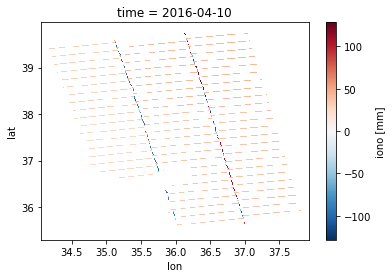

In [36]:
dn['iono'][6].plot()

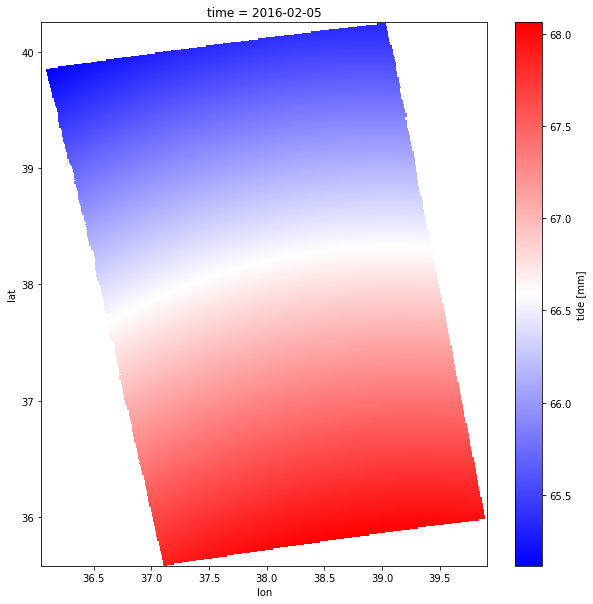

In [17]:
dn['tide'][2].plot(cmap='bwr', figsize=(10,10))

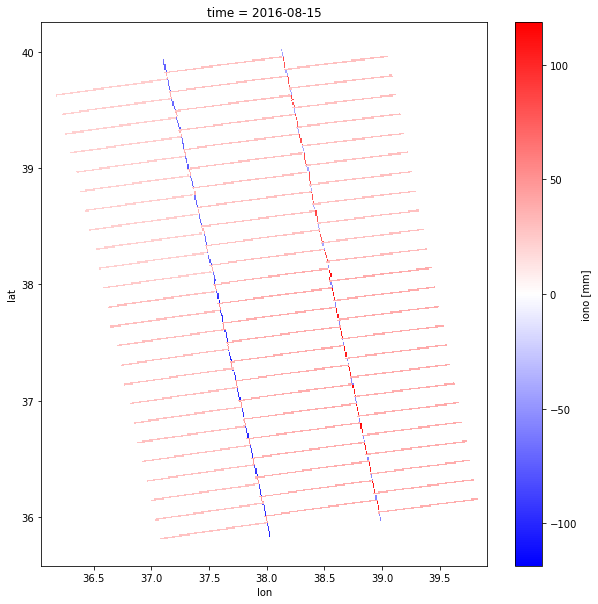

In [23]:
dn['iono'][16].plot(cmap='bwr', figsize=(10,10))

In [19]:
dn['iono'][2]

<xarray.DataArray 'iono' (lat: 468, lon: 387)>
array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       ..., 
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan]], dtype=float32)
Coordinates:
    time     datetime64[ns] 2016-02-05
  * lat      (lat) float64 35.58 35.59 35.6 35.61 ... 40.22 40.23 40.24 40.25
  * lon      (lon) float64 36.05 36.06 36.07 36.08 ... 39.88 39.89 39.9 39.91
Attributes:
    unit:          mm
    grid_mapping:  spatial_ref

In [24]:
export_xr2tif(dn['iono'][16],f'trial_iono2_mm.tif')

/gws/smf/j04/nceo_geohazards/software/mambalics/lib/python3.8/site-packages/xarray/core/dataarray.py:866: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  return key in self.data


WARNING - command did not exit as OK


mv: cannot stat 'trial_iono2_mm.tif': No such file or directory


In [215]:
reflon, reflat = dn.attrs['ref_lon'], dn.attrs['ref_lat']

In [223]:
dn['cum'].sel(lon=reflon, lat=reflat, method='nearest')

<xarray.DataArray 'cum' (time: 61)>
array([ nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2020-01-02 2020-01-08 ... 2020-12-27
    lat      float64 39.46
    lon      float64 35.26
Attributes:
    grid_mapping:  spatial_ref

In [219]:
dn['tide'].sel(lon=reflon, lat=reflat, method='nearest')

<xarray.DataArray 'tide' (time: 61)>
array([        nan,  0.02347755,  0.00987053,  0.01062584,  0.02547598,
       -0.00067425,  0.02823067,  0.0026989 ,  0.0155201 ,  0.02194977,
       -0.00118303,  0.03017426, -0.0008316 ,  0.01630592,  0.01804161,
       -0.00236702,  0.02701783, -0.00240135,  0.01397324,  0.01388359,
       -0.00458908,  0.02113152, -0.00400734,  0.01094913,  0.00977898,
       -0.00631714,  0.01649666, -0.00539207,  0.00966525,  0.00568581,
       -0.00419426,  0.01442528, -0.00508118,  0.01120186,  0.00284386,
        0.00155163,  0.01521492, -0.00285983,  0.01548386,  0.0028801 ,
        0.00740337,  0.01835823, -0.00065756,  0.02226806,  0.00354242,
        0.01195526,  0.02177334, -0.00062943,  0.02975178,  0.00248671,
        0.01536369,  0.02333763, -0.00239182,  0.03394318,  0.00059986,
        0.01823235,  0.02194399, -0.00225258,  0.03290176, -0.00056648,
        0.02135277], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2020-01-02 2020-01-08 ... 2020-12-27
    lat      float64 39.46
    lon      float64 35.26
Attributes:
    unit:          mm
    grid_mapping:  spatial_ref

In [220]:
dn['iono'].sel(lon=reflon, lat=reflat, method='nearest')

<xarray.DataArray 'iono' (time: 61)>
array([ nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2020-01-02 2020-01-08 ... 2020-12-27
    lat      float64 39.46
    lon      float64 35.26
Attributes:
    unit:          mm
    grid_mapping:  spatial_ref

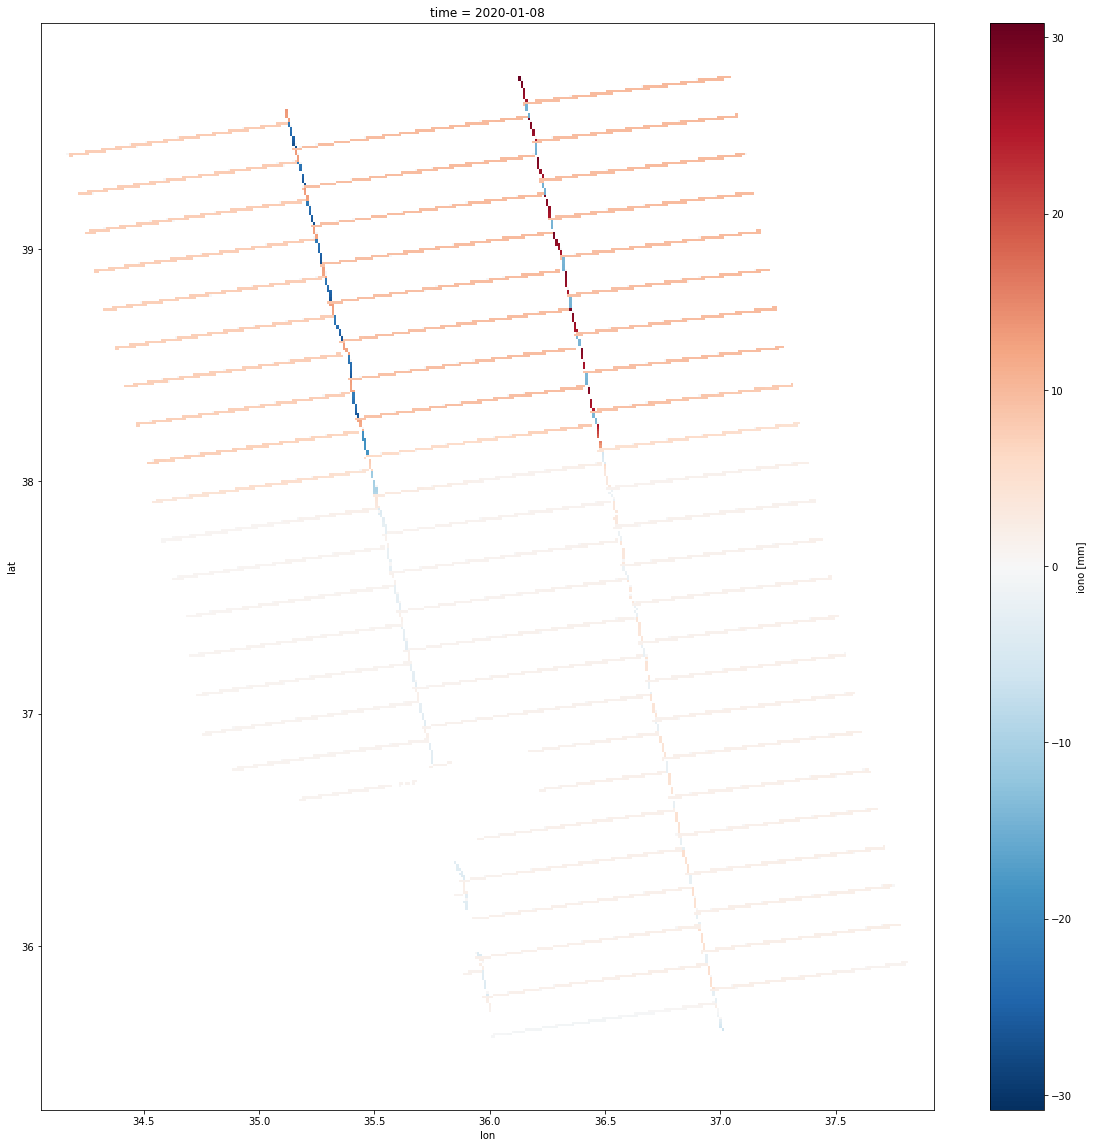

In [226]:
dn['iono'][1].plot(figsize=(20,20))

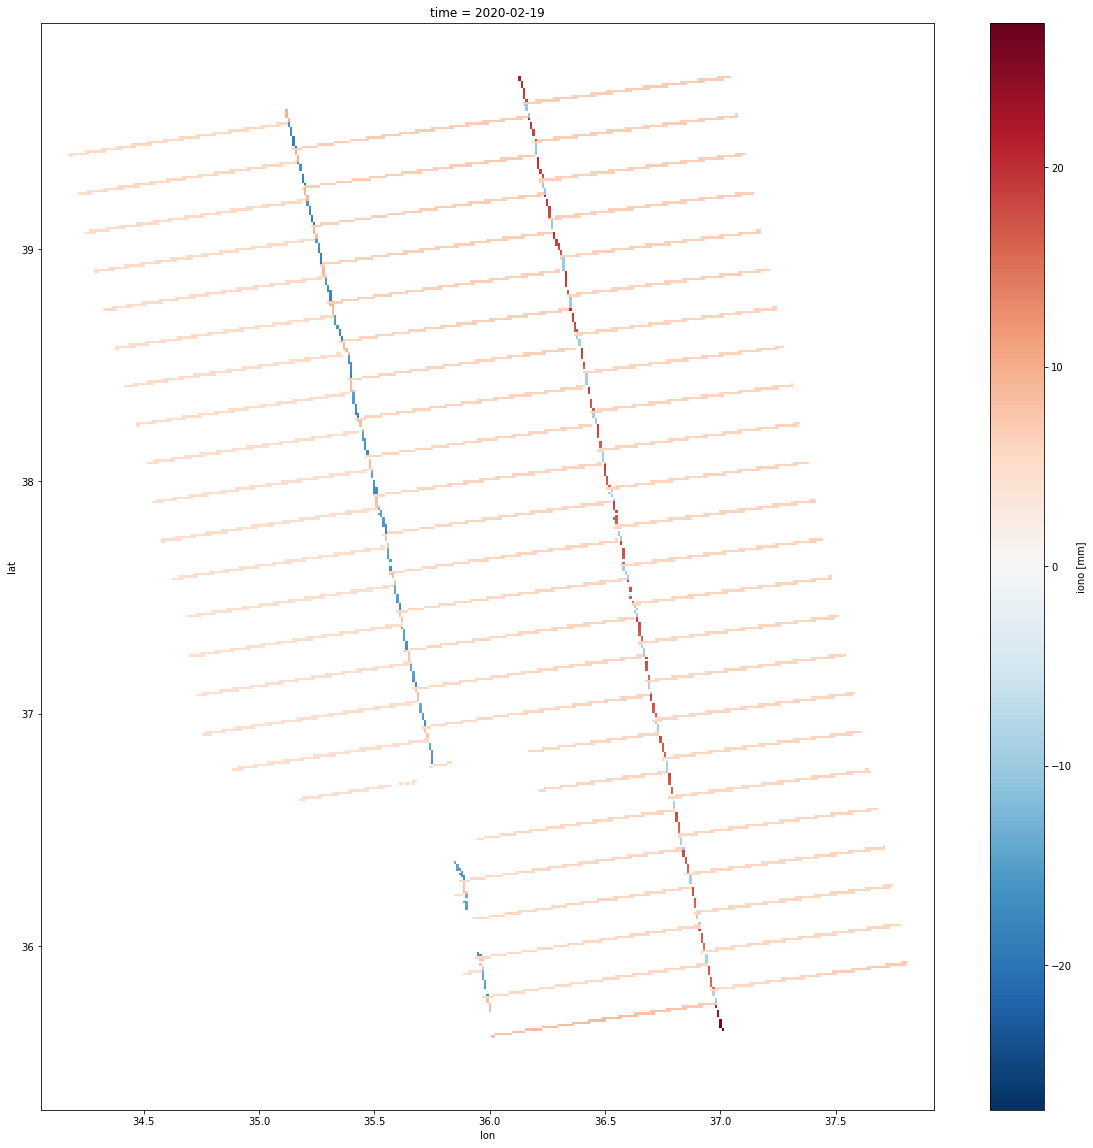

In [233]:
dn['iono'][8].plot(figsize=(20,20))

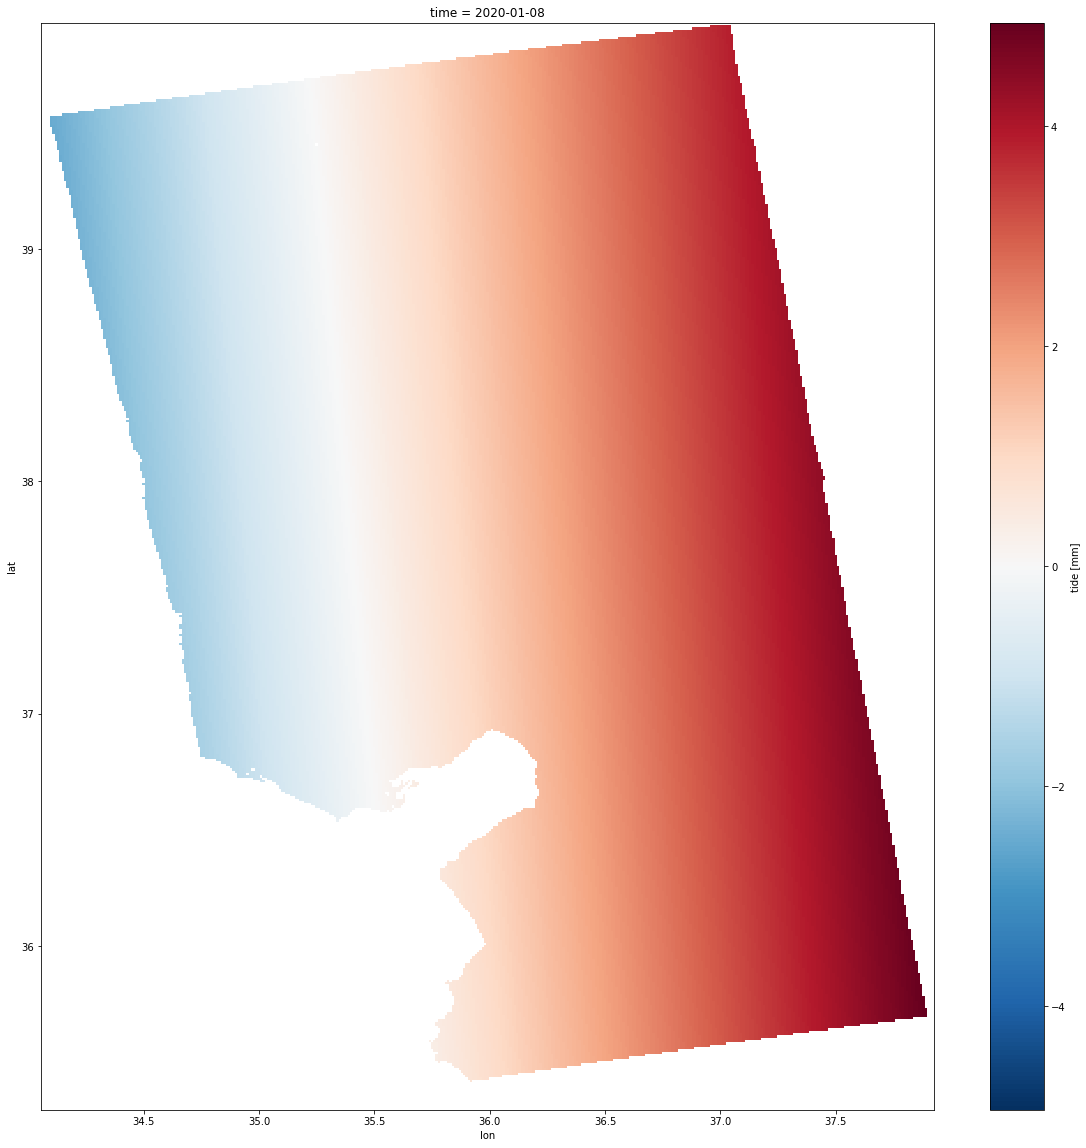

In [217]:
dn['tide'][1].plot(figsize=(20,20))

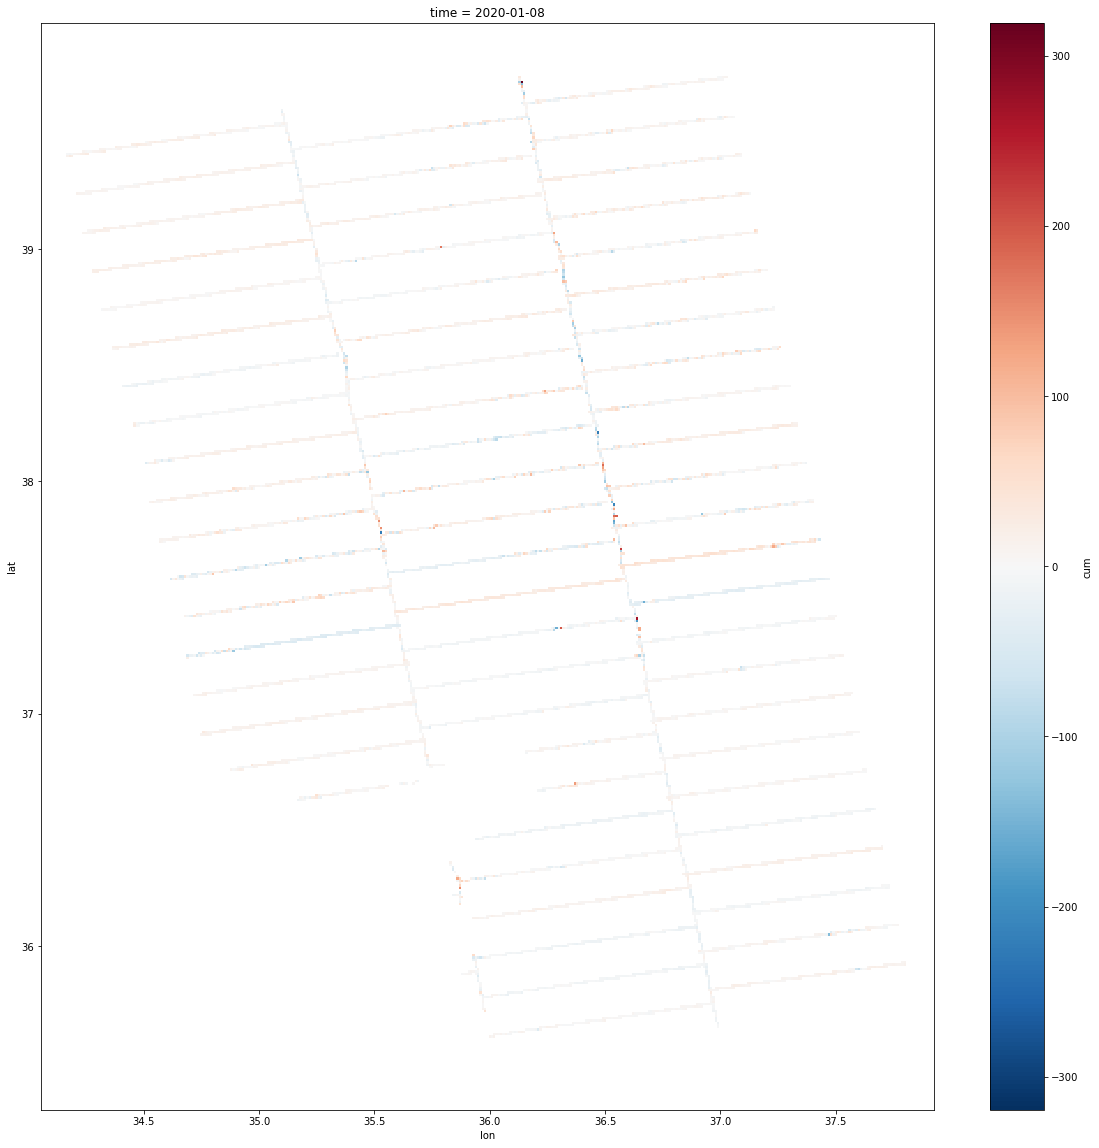

In [206]:
dn['cum'][1].plot(figsize=(20,20))

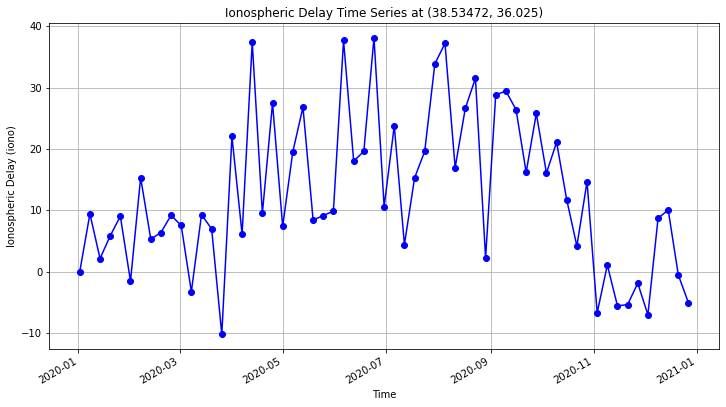

In [240]:
import matplotlib.pyplot as plt

# Define the target latitude and longitude
lat_point = 38.53472  # Example latitude
lon_point = 36.0250  # Example longitude

# Extract the time series at the given coordinate
time_series = cumxr_iono.sel(lat=lat_point, lon=lon_point, method="nearest")

# Plot the time series
plt.figure(figsize=(12, 6))
time_series.plot(marker="o", linestyle="-", color="b")

# Customize the plot
plt.title(f"Ionospheric Delay Time Series at ({lat_point}, {lon_point})")
plt.xlabel("Time")
plt.ylabel("Ionospheric Delay (iono)")
plt.grid()

# Show the plot
plt.show()


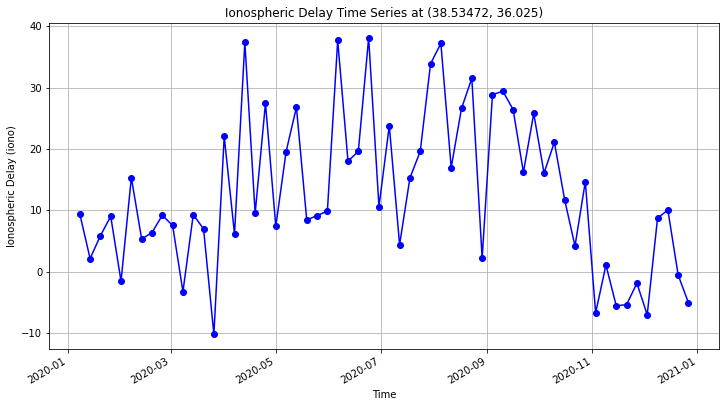

In [237]:
import matplotlib.pyplot as plt

# Define the target latitude and longitude
lat_point = 38.53472  # Example latitude
lon_point = 36.0250  # Example longitude

# Extract the time series at the given coordinate
time_series = dn["iono"].sel(lat=lat_point, lon=lon_point, method="nearest")

# Plot the time series
plt.figure(figsize=(12, 6))
time_series.plot(marker="o", linestyle="-", color="b")

# Customize the plot
plt.title(f"Ionospheric Delay Time Series at ({lat_point}, {lon_point})")
plt.xlabel("Time")
plt.ylabel("Ionospheric Delay (iono)")
plt.grid()

# Show the plot
plt.show()


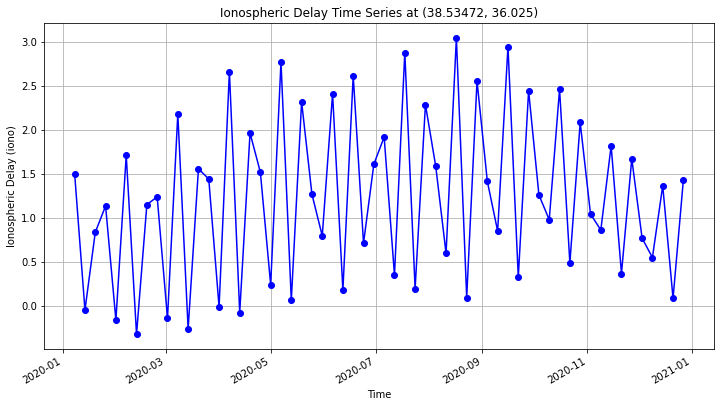

In [238]:
import matplotlib.pyplot as plt

# Define the target latitude and longitude
lat_point = 38.53472  # Example latitude
lon_point = 36.0250  # Example longitude

# Extract the time series at the given coordinate
time_series = dn["tide"].sel(lat=lat_point, lon=lon_point, method="nearest")

# Plot the time series
plt.figure(figsize=(12, 6))
time_series.plot(marker="o", linestyle="-", color="b")

# Customize the plot
plt.title(f"Ionospheric Delay Time Series at ({lat_point}, {lon_point})")
plt.xlabel("Time")
plt.ylabel("Ionospheric Delay (iono)")
plt.grid()

# Show the plot
plt.show()
